# House Price Prediction (Regression)



## 1. Import Required Libraries

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


## 2. Load the Dataset

In [3]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'house_price_regression_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Check Dataset

In [4]:
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Summary statistics:')
df.describe().T

Shape: (1000, 8)

Data types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.50000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.00000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.00000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.00000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.80974,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.00000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.00000,8.000000,1.000000e+01
House_Price,1000.0,618861.018646,253568.058372,111626.853400,401648.228900,628267.29115,827141.277625,1.108237e+06


## 4. Handle Missing Values

In [5]:
missing_values = df.isna().sum()
missing_values

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Observation:** No missing values are present, so no imputation is required.

## 5. Remove Duplicate Records

In [6]:
duplicate_rows = df.duplicated().sum()
print('Duplicate rows:', duplicate_rows)
if duplicate_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)
else:
    print('No duplicates found, so the dataset is unchanged.')

Duplicate rows: 0
No duplicates found, so the dataset is unchanged.


## 6. Perform Univariate Analysis

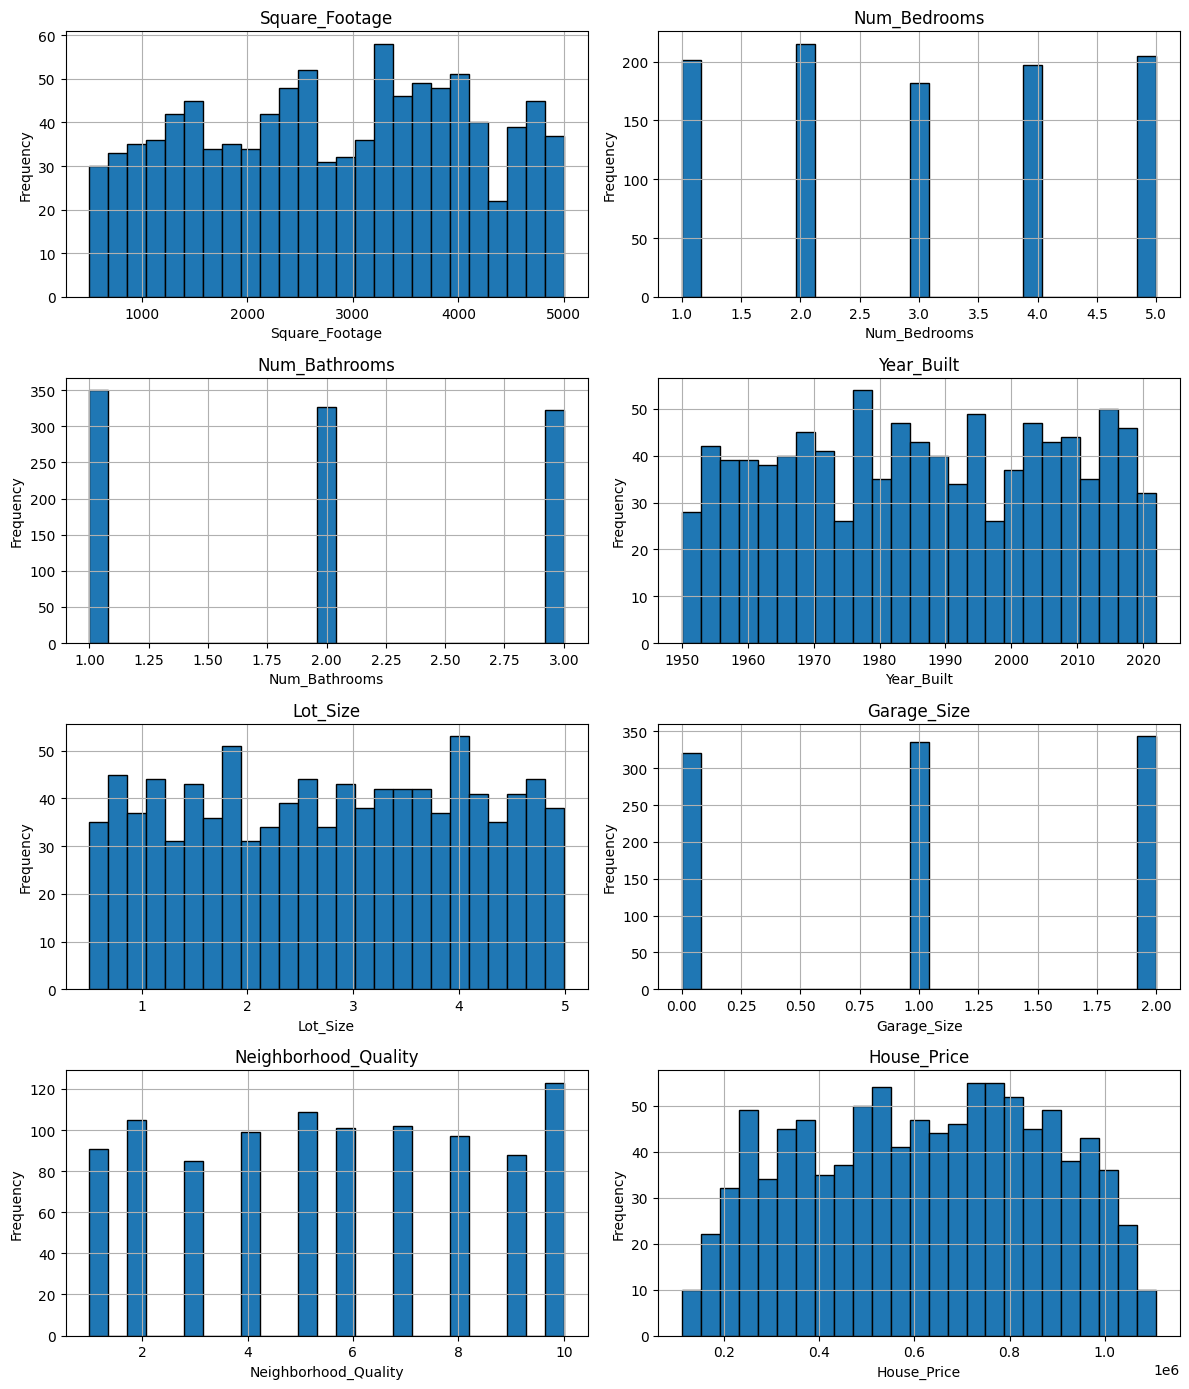

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()
for ax, column in zip(axes, df.columns):
    ax.hist(df[column], bins=25, edgecolor='black')
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 7. Perform Bivariate Analysis

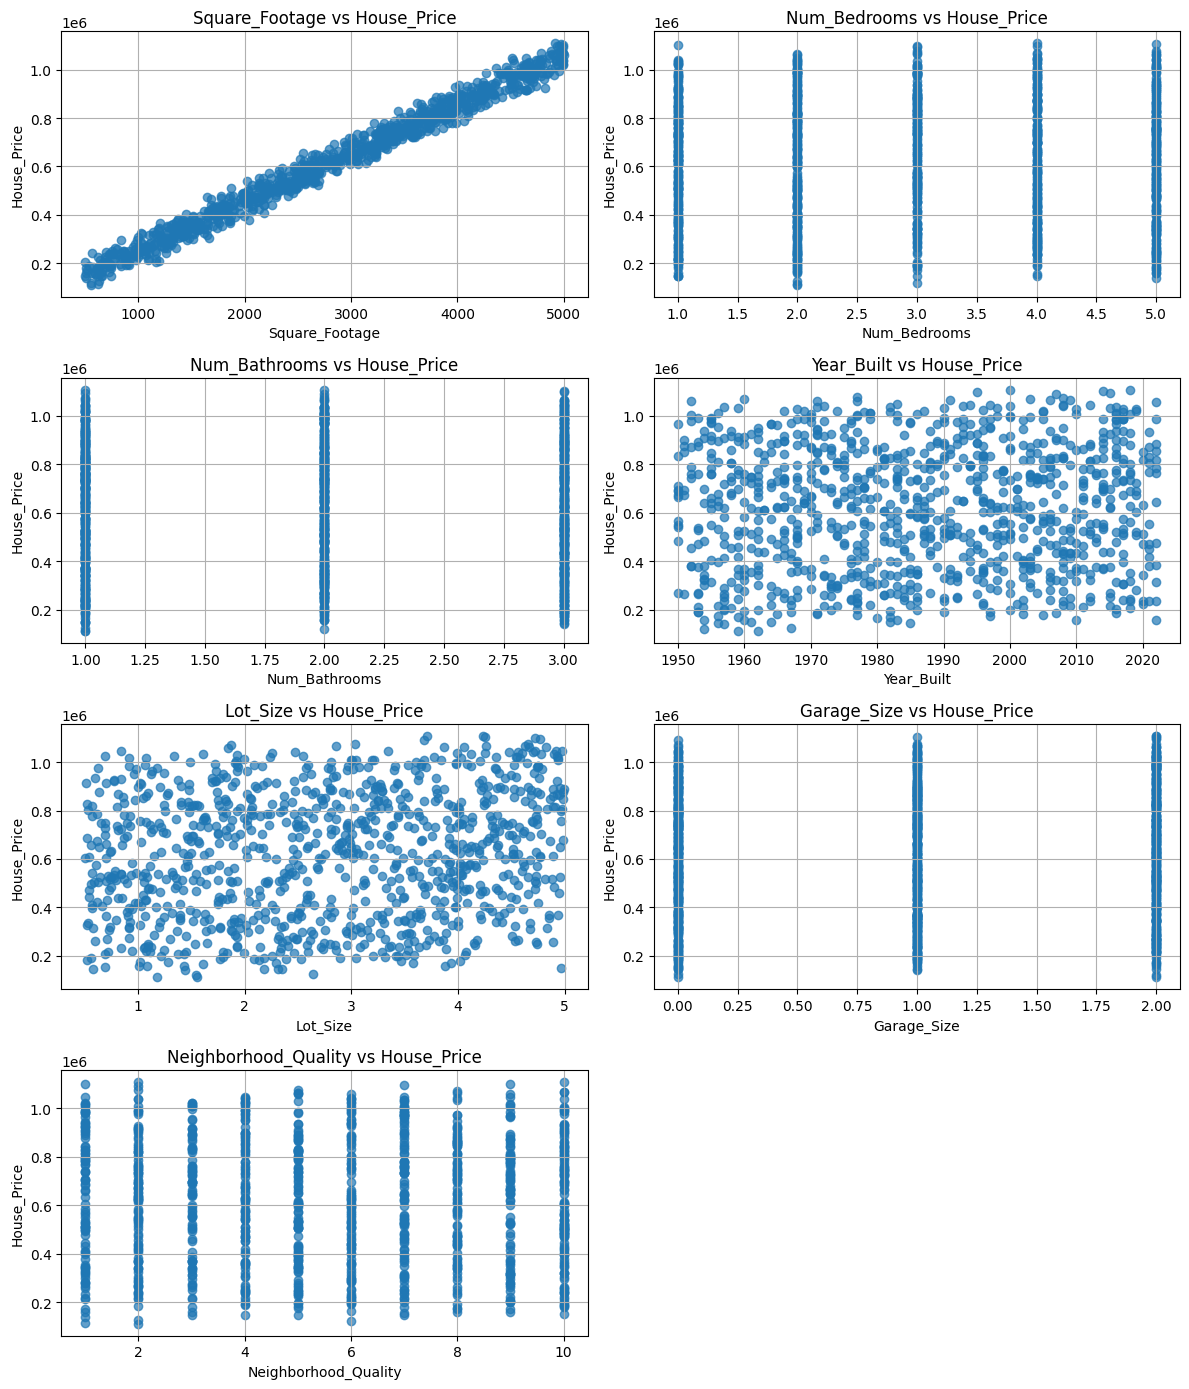

In [8]:
feature_cols = [col for col in df.columns if col != 'House_Price']
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()
for i, column in enumerate(feature_cols):
    axes[i].scatter(df[column], df['House_Price'], alpha=0.7)
    axes[i].set_title(f'{column} vs House_Price')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('House_Price')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 8. Generate Correlation Heatmap

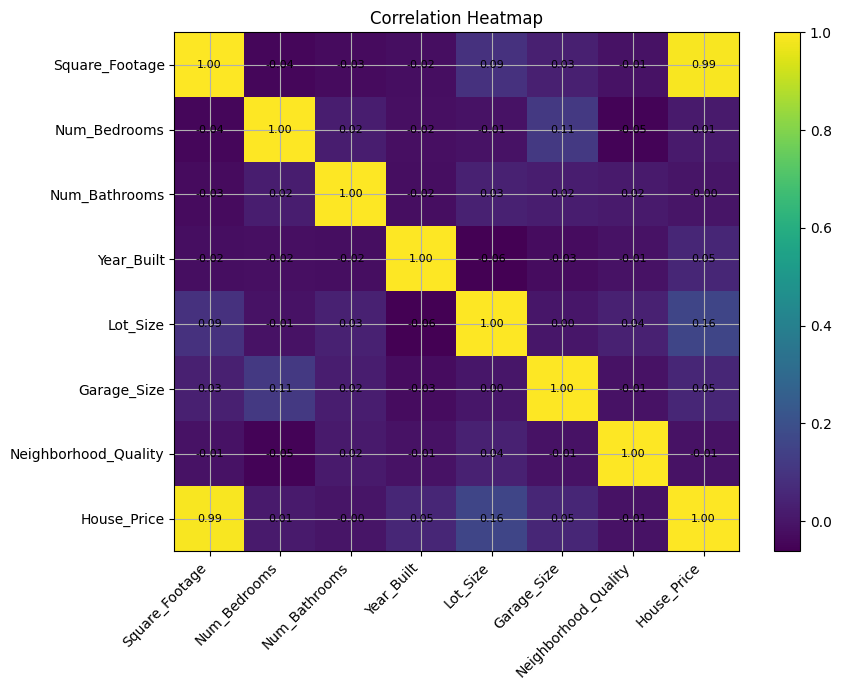

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


In [9]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr['House_Price'].sort_values(ascending=False)

## 9. Detect and Handle Outliers

In [10]:
outlier_counts = {}
for col in df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

pd.Series(outlier_counts, name='IQR_Outlier_Count')

,IQR_Outlier_Count
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Observation:** No IQR-based outliers were detected, so no rows were removed or capped.

## 10. Apply Encoding (if categorical variables exist)

In [11]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', categorical_columns)
print('Encoding required:', 'Yes' if categorical_columns else 'No')

Categorical columns: []
Encoding required: No


**Observation:** All variables are numeric, so encoding is not required for this dataset.

## 11. Apply Log Transformation

In [12]:
skewness = df.skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
skewness

,0
Square_Footage,-0.066001
House_Price,-0.063955
Num_Bathrooms,0.049917
Lot_Size,-0.044288
Garage_Size,-0.040400
Num_Bedrooms,0.025884
Year_Built,-0.021254
Neighborhood_Quality,-0.020445


The skewness values are already very small, so strong log transformation is not necessary. To still satisfy the task requirement, an optional **log-transformed target model** is tested later and compared with the baseline models.

## 12. Separate Features and Target Variable

In [13]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (1000, 7)
Target shape: (1000,)


## 13. Perform Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (800, 7)
X_test : (200, 7)
y_train: (800,)
y_test : (200,)


## 14. Apply Feature Scaling

In [15]:
# Scaling is applied inside the model pipelines so that the exact same transformation
# learned from the training data is also applied to the test data.
from sklearn.pipeline import Pipeline
print('Feature scaling will be applied using StandardScaler inside each pipeline.')

Feature scaling will be applied using StandardScaler inside each pipeline.


## 15. Train Regression Models

In [16]:
linear_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

knn_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=7, weights='distance', p=2))
])

log_linear_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

linear_regression.fit(X_train, y_train)
knn_regression.fit(X_train, y_train)
log_linear_regression.fit(X_train, y_train)

linear_pred = linear_regression.predict(X_test)
knn_pred = knn_regression.predict(X_test)
log_pred = log_linear_regression.predict(X_test)
print('Models trained successfully.')

Models trained successfully.


## 16. Evaluate Models Using MAE, MSE, RMSE, MAPE, R², and Adjusted R²

In [17]:
def evaluate_regression(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Adjusted_R2': adjusted_r2,
    }

results = pd.DataFrame([
    {'Model': 'Linear Regression', **evaluate_regression(y_test, linear_pred, X.shape[1])},
    {'Model': 'KNN Regression (k=7, distance)', **evaluate_regression(y_test, knn_pred, X.shape[1])},
    {'Model': 'Linear Regression with Log Target', **evaluate_regression(y_test, log_pred, X.shape[1])},
]).sort_values('R2', ascending=False)

results

,Model,MAE,MSE,RMSE,MAPE,R2,Adjusted_R2
0,Linear Regression,8174.583600,1.014348e+08,10071.484421,1.663906,0.998426,0.998369
2,Linear Regression with Log Target,51521.693739,4.485156e+09,66971.309881,9.332199,0.930418,0.927881
1,"KNN Regression (k=7, distance)",64689.855816,6.437487e+09,80233.951178,14.751993,0.900130,0.896489


## Cross-Validation Check

In [18]:
linear_cv_rmse = -cross_val_score(
    linear_regression, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error'
).mean()
knn_cv_rmse = -cross_val_score(
    knn_regression, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error'
).mean()

pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regression (k=7, distance)'],
    'CV_RMSE': [linear_cv_rmse, knn_cv_rmse]
})

,Model,CV_RMSE
0,Linear Regression,9747.432896
1,"KNN Regression (k=7, distance)",80932.710884


## Actual vs Predicted Plots

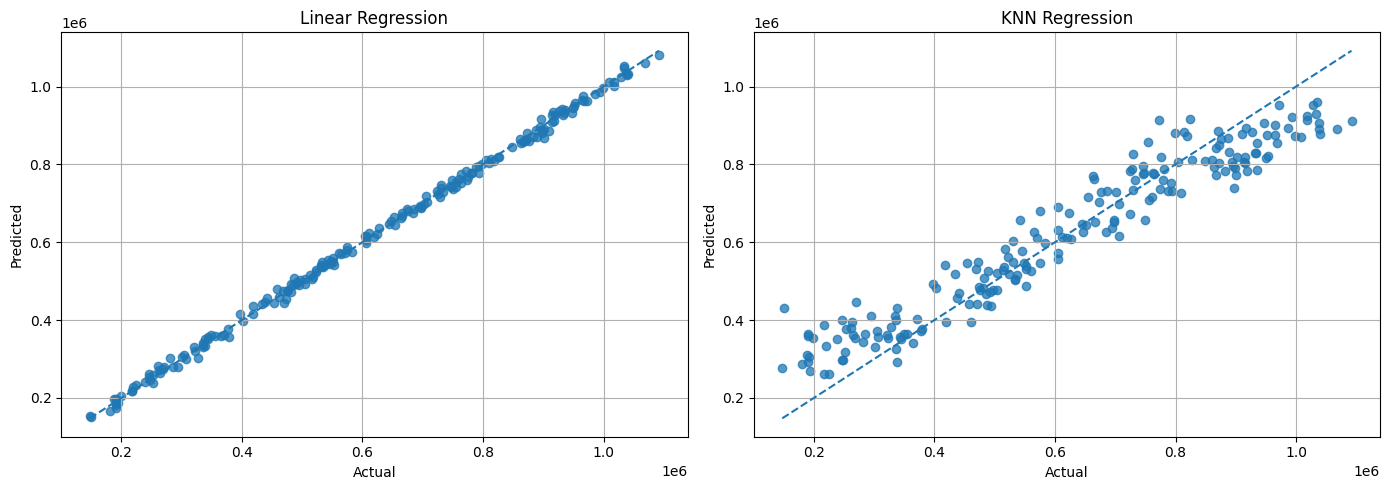

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, linear_pred, alpha=0.75)
low = min(y_test.min(), linear_pred.min())
high = max(y_test.max(), linear_pred.max())
axes[0].plot([low, high], [low, high], linestyle='--')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, knn_pred, alpha=0.75)
low = min(y_test.min(), knn_pred.min())
high = max(y_test.max(), knn_pred.max())
axes[1].plot([low, high], [low, high], linestyle='--')
axes[1].set_title('KNN Regression')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

## Linear Regression Coefficients

In [20]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Standardized_Coefficient': linear_regression.named_steps['model'].coef_
}).sort_values('Standardized_Coefficient', key=lambda s: s.abs(), ascending=False)
coef_df

,Feature,Standardized_Coefficient
0,Square_Footage,249787.914838
3,Year_Built,20662.121610
4,Lot_Size,19088.111034
1,Num_Bedrooms,14524.734401
2,Num_Bathrooms,6695.906770
5,Garage_Size,4219.449422
6,Neighborhood_Quality,335.247487


## 18. Save the Best Model Using Pickle (.pkl)

The best-performing model is saved as a `.pkl` file so it can be reused later in a Streamlit app or any other Python script without retraining the model. The saved artifact includes the trained pipeline, feature column order, target column name, and evaluation summary.


In [21]:
# Select the best model based on the evaluation results
best_model_name = results.iloc[0]['Model']

if best_model_name == 'Linear Regression':
    best_model = linear_regression
elif best_model_name == 'KNN Regression (k=7, distance)':
    best_model = knn_regression
else:
    best_model = log_linear_regression

model_artifact = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_columns': X.columns.tolist(),
    'target_column': 'House_Price',
    'evaluation_results': results.to_dict(orient='records')
}

PKL_PATH = BASE_DIR / 'house_price_model.pkl'

with open(PKL_PATH, 'wb') as file:
    pickle.dump(model_artifact, file)

print(f'Best model saved successfully as: {PKL_PATH}')
print(f'Saved model: {best_model_name}')


Best model saved successfully as: /content/house_price_model.pkl
Saved model: Linear Regression


## 19. Load the Pickle Model and Test Prediction

This step confirms that the saved `.pkl` file can be loaded correctly and used for prediction. This is the same loading logic that can be used in a Streamlit interface.


In [22]:
with open(PKL_PATH, 'rb') as file:
    loaded_artifact = pickle.load(file)

loaded_model = loaded_artifact['model']
loaded_features = loaded_artifact['feature_columns']

# Test loaded model on one sample from the test data
sample_input = X_test.iloc[[0]][loaded_features]
loaded_prediction = loaded_model.predict(sample_input)[0]
actual_value = y_test.iloc[0]

print('Model loaded successfully from pickle file.')
print(f'Loaded model name: {loaded_artifact["model_name"]}')
print(f'Actual House Price   : {actual_value:,.2f}')
print(f'Predicted House Price: {loaded_prediction:,.2f}')


Model loaded successfully from pickle file.
Loaded model name: Linear Regression
Actual House Price   : 901,000.49
Predicted House Price: 868,687.11


## 20. Predict Price for New House Data Using Loaded Model

The loaded model can also predict the price of a completely new house record. The new input must contain the same feature names and order used during training.


In [23]:
# Example new house input created from median feature values
# Replace these values with user inputs in a Streamlit app
new_house = pd.DataFrame([X.median(numeric_only=True)])
new_house = new_house[loaded_features]

new_prediction = loaded_model.predict(new_house)[0]
print(f'Predicted price for new house data: {new_prediction:,.2f}')

new_house


Predicted price for new house data: 628,457.17


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,2862.5,3.0,2.0,1986.0,2.80974,1.0,6.0


## 21. Streamlit Loading Logic for the Pickle Model

Use this logic inside a Streamlit app to load the saved `.pkl` model and make predictions. Keep `house_price_model.pkl` in the same folder as your Streamlit Python file.


In [24]:
# Example Streamlit-compatible loading code
# Copy this logic into your Streamlit app if needed.

# import pickle
# import pandas as pd
# import streamlit as st
# from pathlib import Path
#
# @st.cache_resource
# def load_model():
#     with open(Path('house_price_model.pkl'), 'rb') as file:
#         artifact = pickle.load(file)
#     return artifact
#
# artifact = load_model()
# model = artifact['model']
# feature_columns = artifact['feature_columns']
#
# input_data = pd.DataFrame([{
#     'feature_1': value_1,
#     'feature_2': value_2
# }])
# input_data = input_data[feature_columns]
# prediction = model.predict(input_data)[0]
# st.success(f'Predicted House Price: {prediction:,.2f}')


## Final Conclusion

- The dataset is already clean: no missing values, no duplicate rows, no categorical columns, and no IQR-detected outliers.
- `Square_Footage` has an extremely strong positive relationship with `House_Price`, which explains why the linear model performs exceptionally well.
- **Linear Regression is the best model** on this dataset, clearly outperforming KNN regression and the optional log-transformed target model.
- The final trained model is saved as `house_price_model.pkl`, allowing reuse in Streamlit or other Python applications without retraining.


## GitHub Link Placeholder

`https://github.com/anshul55555/house-price-regression`